Época [1/20], Loss: 0.3234
Época [2/20], Loss: 0.2440
Época [3/20], Loss: 0.2057
Época [4/20], Loss: 0.1807
Época [5/20], Loss: 0.1653
Época [6/20], Loss: 0.1565
Época [7/20], Loss: 0.1489
Época [8/20], Loss: 0.1438
Época [9/20], Loss: 0.1400
Época [10/20], Loss: 0.1371
Época [11/20], Loss: 0.1345
Época [12/20], Loss: 0.1317
Época [13/20], Loss: 0.1295
Época [14/20], Loss: 0.1277
Época [15/20], Loss: 0.1262
Época [16/20], Loss: 0.1249
Época [17/20], Loss: 0.1236
Época [18/20], Loss: 0.1223
Época [19/20], Loss: 0.1212
Época [20/20], Loss: 0.1202


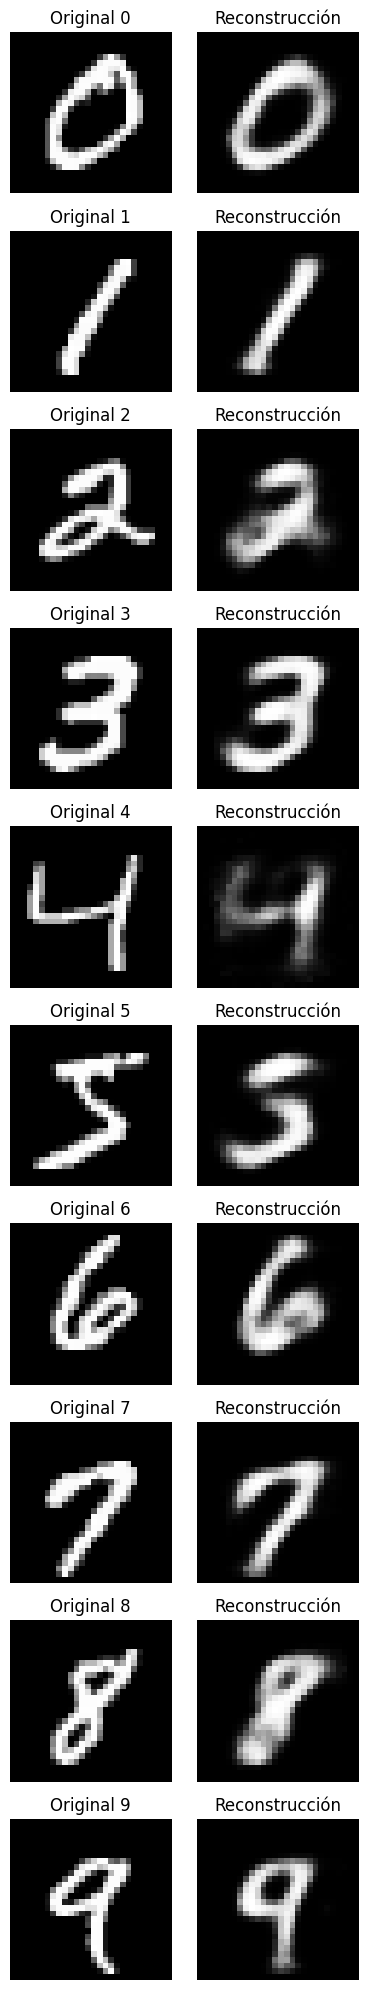

In [7]:
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 19 11:18:35 2026

@author: vanes
"""
"""
Ejercicio 1.
""" 
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transformación: tensor + normalización [0,1]
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()  # salida en [0,1]
        )
    
    def forward(self, x):
        x = x.view(-1, 784)  # Aplanar
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum = 0.9)

epochs = 20

for epoch in range(epochs):
    total_loss = 0
    
    for images, _ in train_loader:
        images = images.to(device)
        images = images.view(-1, 784)
        
        outputs = model(images)
        loss = criterion(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Época [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

model.eval()

# Guardar un ejemplo por clase
examples = {i: None for i in range(10)}

for img, label in train_dataset:
    if examples[label] is None:
        examples[label] = img
    if all(v is not None for v in examples.values()):
        break

fig, axes = plt.subplots(10, 2, figsize=(4, 20))

with torch.no_grad():
    for i in range(10):
        original = examples[i].to(device).view(1, -1)
        reconstructed = model(original)
        
        axes[i, 0].imshow(original.cpu().view(28,28), cmap='gray')
        axes[i, 0].set_title(f"Original {i}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(reconstructed.cpu().view(28,28), cmap='gray')
        axes[i, 1].set_title("Reconstrucción")
        axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# #%%
# """
# Ejercicio 2.
# """

# class Autoencoder2D(nn.Module):
#     def __init__(self):
#         super(Autoencoder2D, self).__init__()
        
#         # Encoder: 784 → 128 → 2
#         self.encoder = nn.Sequential(
#             nn.Linear(784, 128),
#             nn.ReLU(),
#             nn.Linear(128, 2)
#         )
        
#         # Decoder: 2 → 128 → 784
#         self.decoder = nn.Sequential(
#             nn.Linear(2, 128),
#             nn.ReLU(),
#             nn.Linear(128, 784),
#             nn.Sigmoid()
#         )
    
#     def forward(self, x):
#         x = x.view(-1, 784)
#         z = self.encoder(x)
#         x_recon = self.decoder(z)
#         return x_recon

# model = Autoencoder2D().to(device)

# criterion = nn.BCELoss()
# optimizer = optim.SGD(model.parameters(), lr=0.1)

# epochs = 20

# for epoch in range(epochs):
#     total_loss = 0
    
#     for images, _ in train_loader:
#         images = images.to(device)
#         images = images.view(-1, 784)
        
#         outputs = model(images)
#         loss = criterion(outputs, images)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
    
#     print(f"Época [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

# model.eval()

# # Guardar un ejemplo por clase
# examples = {i: None for i in range(10)}

# for img, label in train_dataset:
#     if examples[label] is None:
#         examples[label] = img
#     if all(v is not None for v in examples.values()):
#         break

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(10, 2, figsize=(4, 20))

# with torch.no_grad():
#     for i in range(10):
#         original = examples[i].to(device).view(1, -1)
#         reconstructed = model(original)
        
#         axes[i, 0].imshow(original.cpu().view(28,28), cmap='gray')
#         axes[i, 0].set_title(f"Original {i}")
#         axes[i, 0].axis('off')
        
#         axes[i, 1].imshow(reconstructed.cpu().view(28,28), cmap='gray')
#         axes[i, 1].set_title("Reconstrucción")
#         axes[i, 1].axis('off')

# plt.tight_layout()
# plt.show()

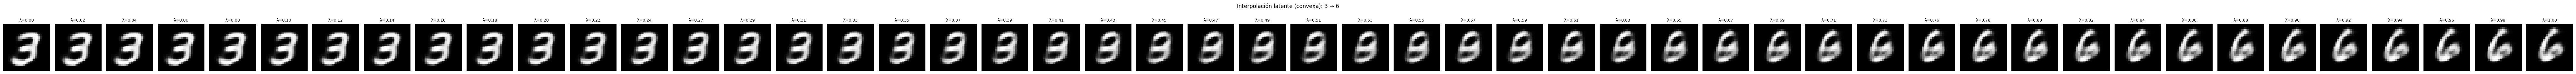

GIF guardado en: c:\Users\mario\Desktop\UCM\Taller de Tecno\pyth\mnist_latent_interpolation.gif


In [16]:
# =========================================================
# EXTRA: Interpolación convexa en el espacio latente + GIF (10 pasos)
# PÉGALO AL FINAL de tu notebook (después de entrenar y hacer model.eval()).
# Funciona con tu Autoencoder (latente=16) y con Autoencoder2D (latente=2),
# porque usa model.encoder y model.decoder directamente.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio  # pip install imageio
import os

# -------------------------
# 1) Elegir dos imágenes (A y B) del dataset (puedes cambiar dígitos)
# -------------------------
def get_one_example_of_digit(dataset, digit):
    for img, label in dataset:
        if label == digit:
            return img, label
    raise ValueError(f"No se encontró el dígito {digit} en el dataset.")

# elige dos dígitos para interpolar (cámbialos a tu gusto)
digit_A = 3
digit_B = 6

imgA, labA = get_one_example_of_digit(train_dataset, digit_A)
imgB, labB = get_one_example_of_digit(train_dataset, digit_B)

# -------------------------
# 2) Interpolar en el espacio latente y decodificar
# -------------------------
@torch.no_grad()
def latent_interpolation_frames(model, imgA, imgB, n_steps=100, device=device):
    """
    Devuelve una lista de frames (np.uint8) para un GIF.
    Interpolación convexa: z(λ) = (1-λ) zA + λ zB, con λ en [0,1].
    n_steps = 10 => 10 valores de λ.
    """
    model.eval()

    # preparar entradas
    xA = imgA.to(device).view(1, -1)  # [1,784]
    xB = imgB.to(device).view(1, -1)

    # codificar
    zA = model.encoder(xA)  # [1,latent]
    zB = model.encoder(xB)

    # lambdas en [0,1] (10 pasos)
    lambdas = torch.linspace(0.0, 1.0, n_steps, device=device)

    frames = []
    for lam in lambdas:
        z = (1.0 - lam) * zA + lam * zB
        x_gen = model.decoder(z).view(28, 28).detach().cpu().numpy()  # [28,28] en [0,1]

        # frame como imagen 0..255
        frame = (x_gen * 255).clip(0, 255).astype(np.uint8)
        frames.append(frame)

    return frames, lambdas.detach().cpu().numpy()

frames, lambdas = latent_interpolation_frames(model, imgA, imgB, n_steps=50, device=device)

# -------------------------
# 3) Mostrar en pantalla la tira de interpolaciones (opcional)
# -------------------------
fig, axes = plt.subplots(1, len(frames), figsize=(1.6 * len(frames), 2.2))
fig.suptitle(f"Interpolación latente (convexa): {digit_A} → {digit_B}", y=1.05)

for i, (ax, fr) in enumerate(zip(axes, frames)):
    ax.imshow(fr, cmap="gray")
    ax.set_title(f"λ={lambdas[i]:.2f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# -------------------------
# 4) Crear GIF (10 frames)
# -------------------------
gif_path = "mnist_latent_interpolation.gif"
# duration = segundos por frame (ajusta a gusto)
imageio.mimsave(gif_path, frames, duration=0.35, loop=0)

print(f"GIF guardado en: {os.path.abspath(gif_path)}")